# Transformer-Enhanced LSTM -- Colab Training Runner

Runs **all three CIC-IDS2017 tasks**: `ids_binary` (Benign vs any attack), `ids_family` (coarse attack families), and `ids_multi` (fine attack types).

Set `REPO_URL` below, then **Runtime -> Run all**.

Make sure **Runtime type = GPU** (Runtime -> Change runtime type -> GPU) before running.

**Slow run?** CIC-IDS2017 is ~2.2M rows after cleaning. If training is too slow on the free Colab GPU, set `SUBSAMPLE_N` in `config.py` (e.g. `500_000`) in your own clone of this repo, push, then re-run this notebook -- it keeps every minority-class (attack) row and only downsamples Benign.

In [1]:
REPO_URL = "https://github.com/abdullah-dev29/network-traffic-classification-transformer-enhanced-lstm--3.0.git"
REPO_DIR = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")

In [2]:
!rm -rf {REPO_DIR} && git clone {REPO_URL}
%cd {REPO_DIR}

Cloning into 'network-traffic-classification-transformer-enhanced-lstm--3.0'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 73 (delta 4), reused 3 (delta 3), pack-reused 65 (from 1)
Receiving objects: 100% (73/73), 237.73 MiB | 14.25 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (20/20), done.
/content/network-traffic-classification-transformer-enhanced-lstm--3.0


In [3]:
!nvidia-smi

Mon Jun 22 15:37:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Install light deps only. Do NOT reinstall tensorflow on Colab --
# Colab ships a CUDA-matched TensorFlow build, and reinstalling breaks GPU support.
!pip install -q pandas pyarrow scikit-learn seaborn matplotlib joblib

import tensorflow as tf
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Task 1: `ids_binary` (Benign vs Attack)

The headline, like-for-like comparison with the CIC-Darknet2020 `binary` task (Phase 2) -- same metric set, same threshold-tuning approach, different dataset.

In [5]:
!python src/train.py    --task ids_binary

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [6]:
!python src/evaluate.py --task ids_binary

2026-06-22 17:51:49.525326: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782150709.526851   38176 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
2790/2790 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step
Best threshold by validation F1: 0.40 (val F1=0.9809)
--- Threshold 0.50 ---
  accuracy: 0.9935
  precision: 0.9846
  recall: 0.9721
  f1: 0.9783
  auc: 0.9996
  specificity: 0.9973
--- Threshold 0.40 (tuned) ---
  accuracy: 0.9935
  precision: 0.9791
  recall: 0.9778
  f1: 0.9785
  auc: 0.9996
  specificity: 0.9963


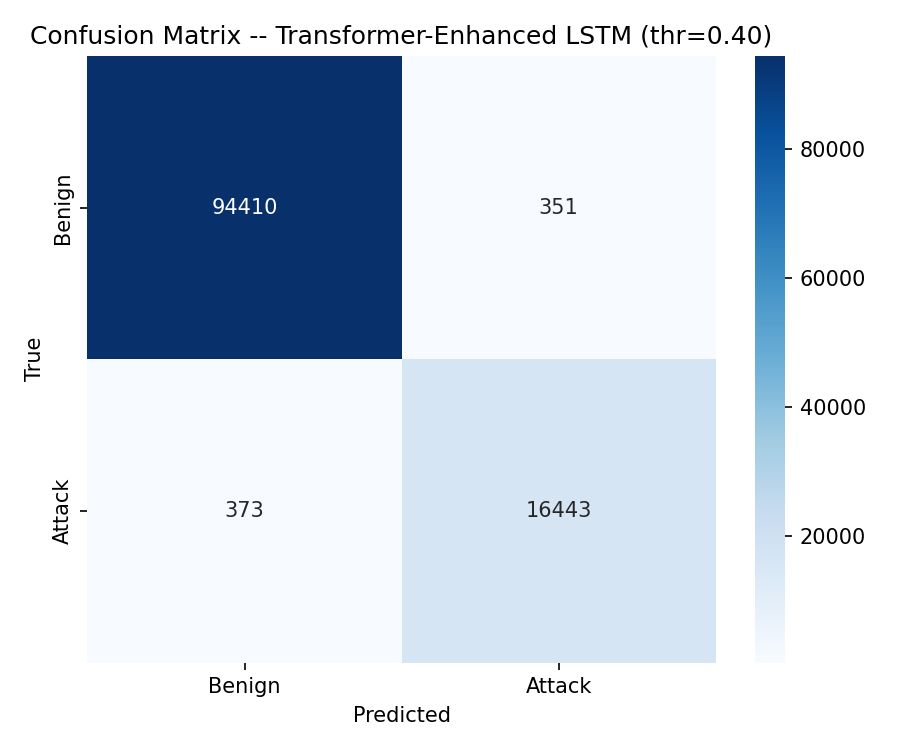

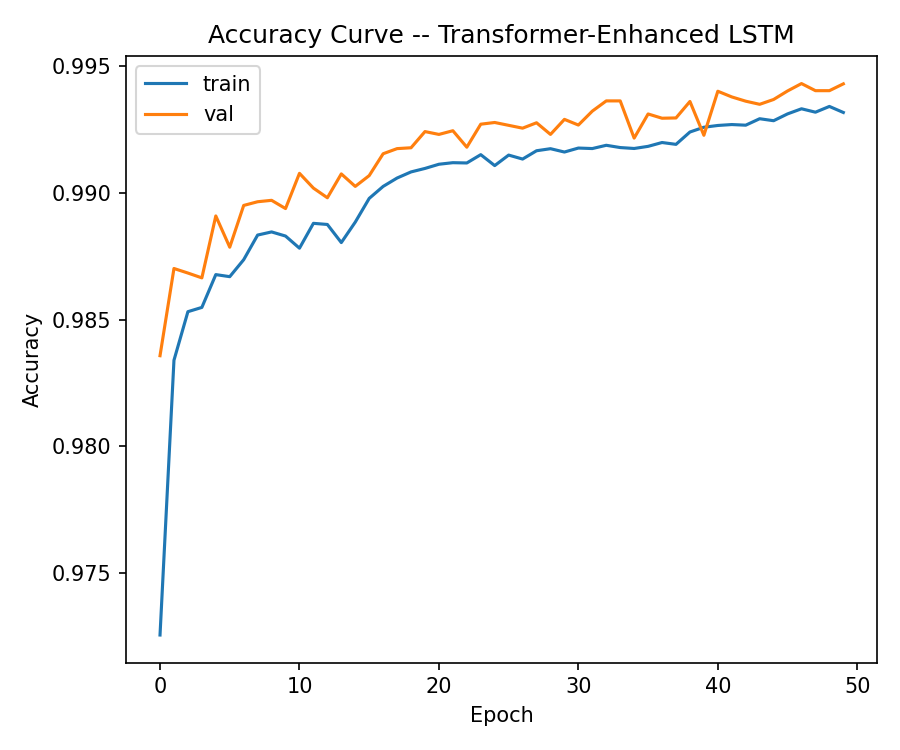

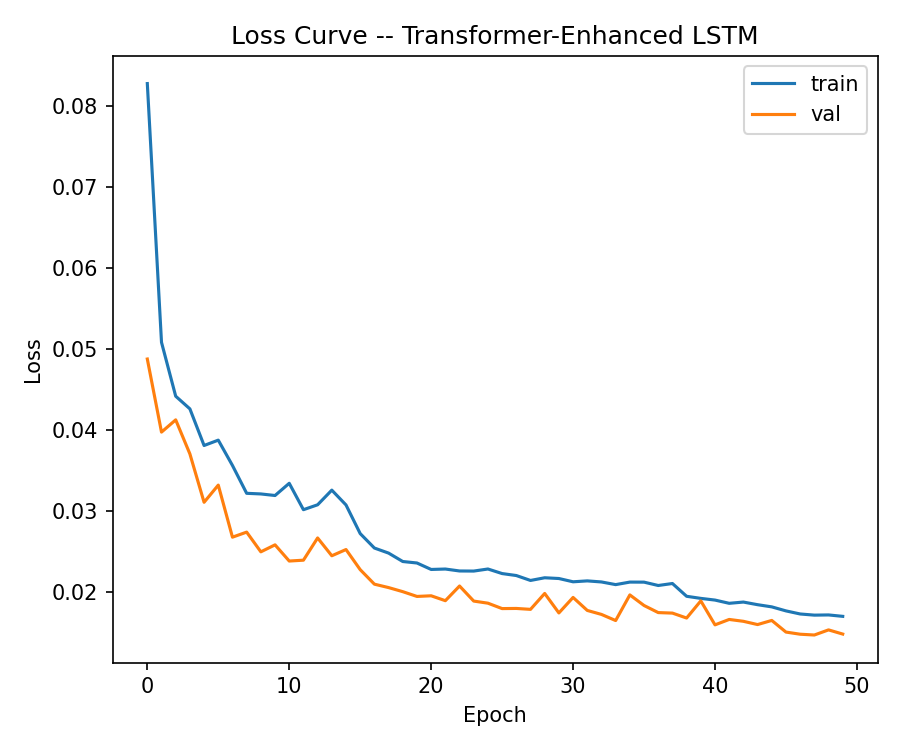

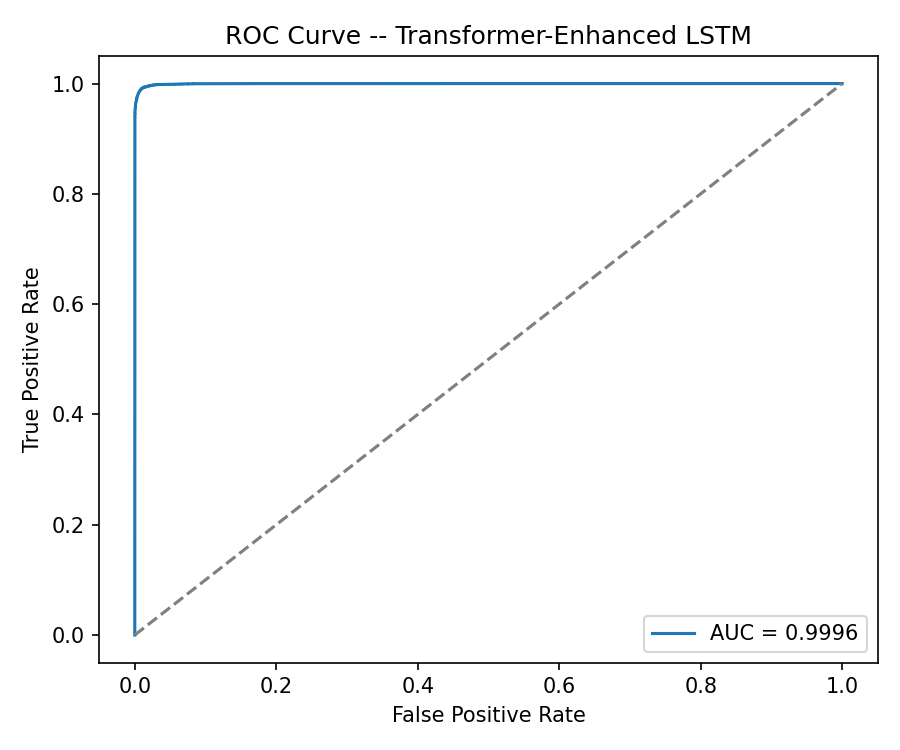

In [7]:
from IPython.display import Image, display

display(Image("results/ids_binary/confusion_matrix.png"))
display(Image("figures/ids_binary/accuracy_curve.png"))
display(Image("figures/ids_binary/loss_curve.png"))
display(Image("figures/ids_binary/roc_curve.png"))

In [8]:
print(open("results/ids_binary/metrics.txt").read())

Model                                       Accuracy        F1    Recall Precision       AUC Specificity
Transformer-Enhanced LSTM (thr=0.50)          0.9935    0.9783    0.9721    0.9846    0.9996      0.9973
Transformer-Enhanced LSTM (thr=best=0.40)     0.9935    0.9785    0.9778    0.9791    0.9996      0.9963



## Task 2: `ids_family` (coarse attack families)

BENIGN plus 7 coarse families (DoS/DDoS, Brute-Force, Web-Attack, Botnet, PortScan, Infiltration, Other). Judge by **macro-F1** and the confusion matrix, not accuracy -- Benign dominates and the rarest families (Infiltration, Other/Heartbleed) are expected to be the weak spots. Not class-comparable to the CIC-Darknet2020 `fourclass` task -- different problem domain, same model generalizing to a second dataset.

In [9]:
!python src/train.py    --task ids_family

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [10]:
!python src/evaluate.py --task ids_family

2026-06-22 19:33:36.362819: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1782156816.364347   64671 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
3487/3487 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step
Accuracy:        0.0041
Macro F1:        0.0010
Weighted F1:     0.0000
Macro Precision: 0.0005
Macro Recall:    0.1250
Macro AUC (OvR): 0.5000
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_c

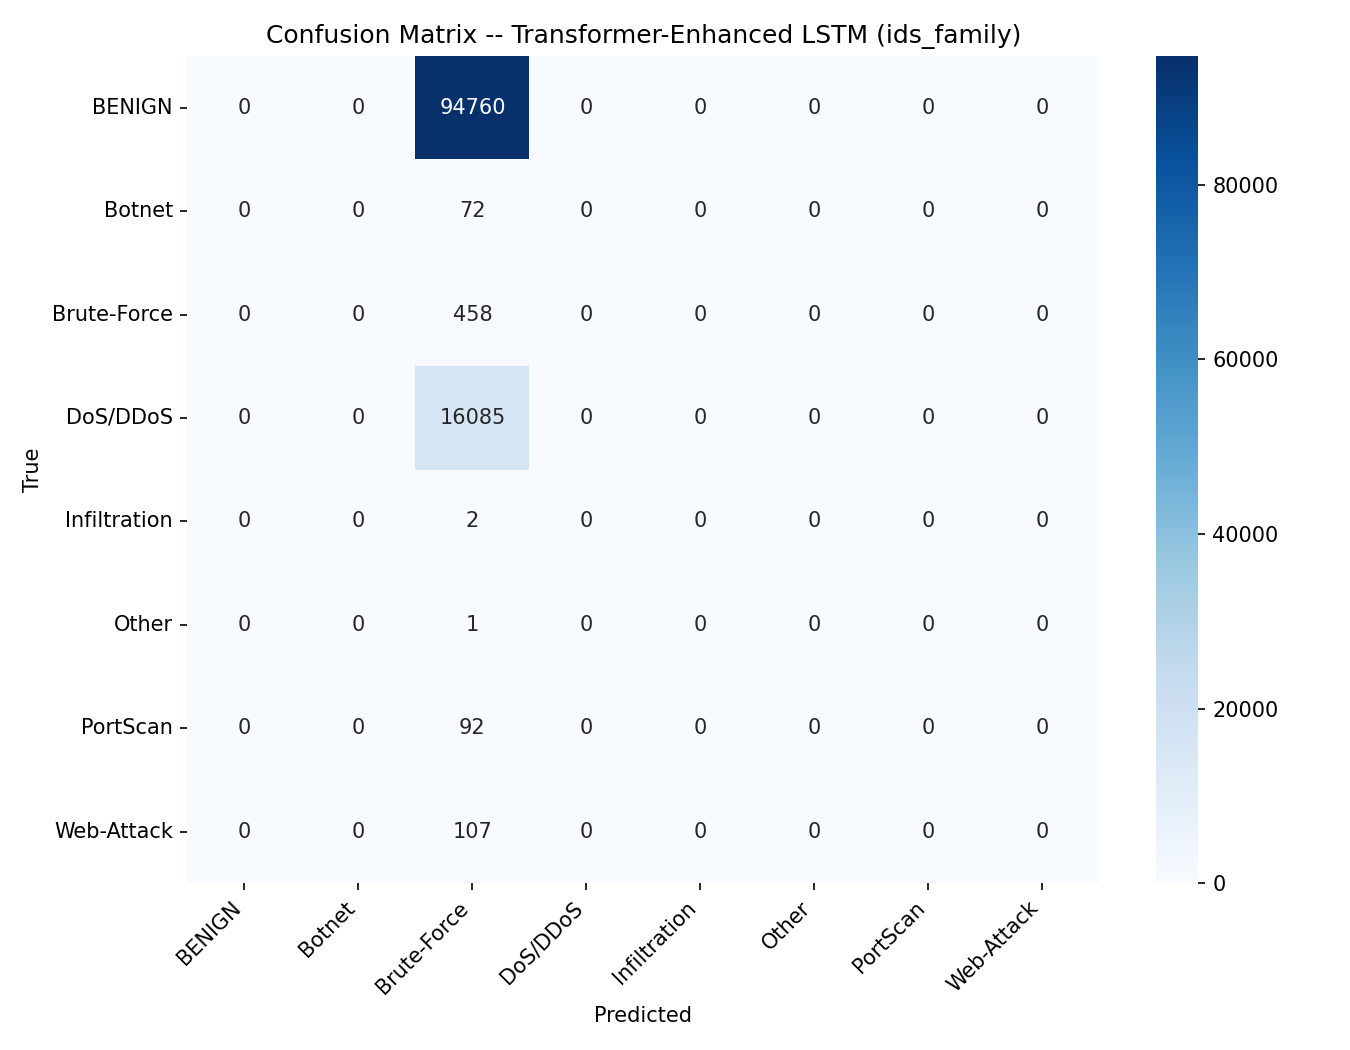

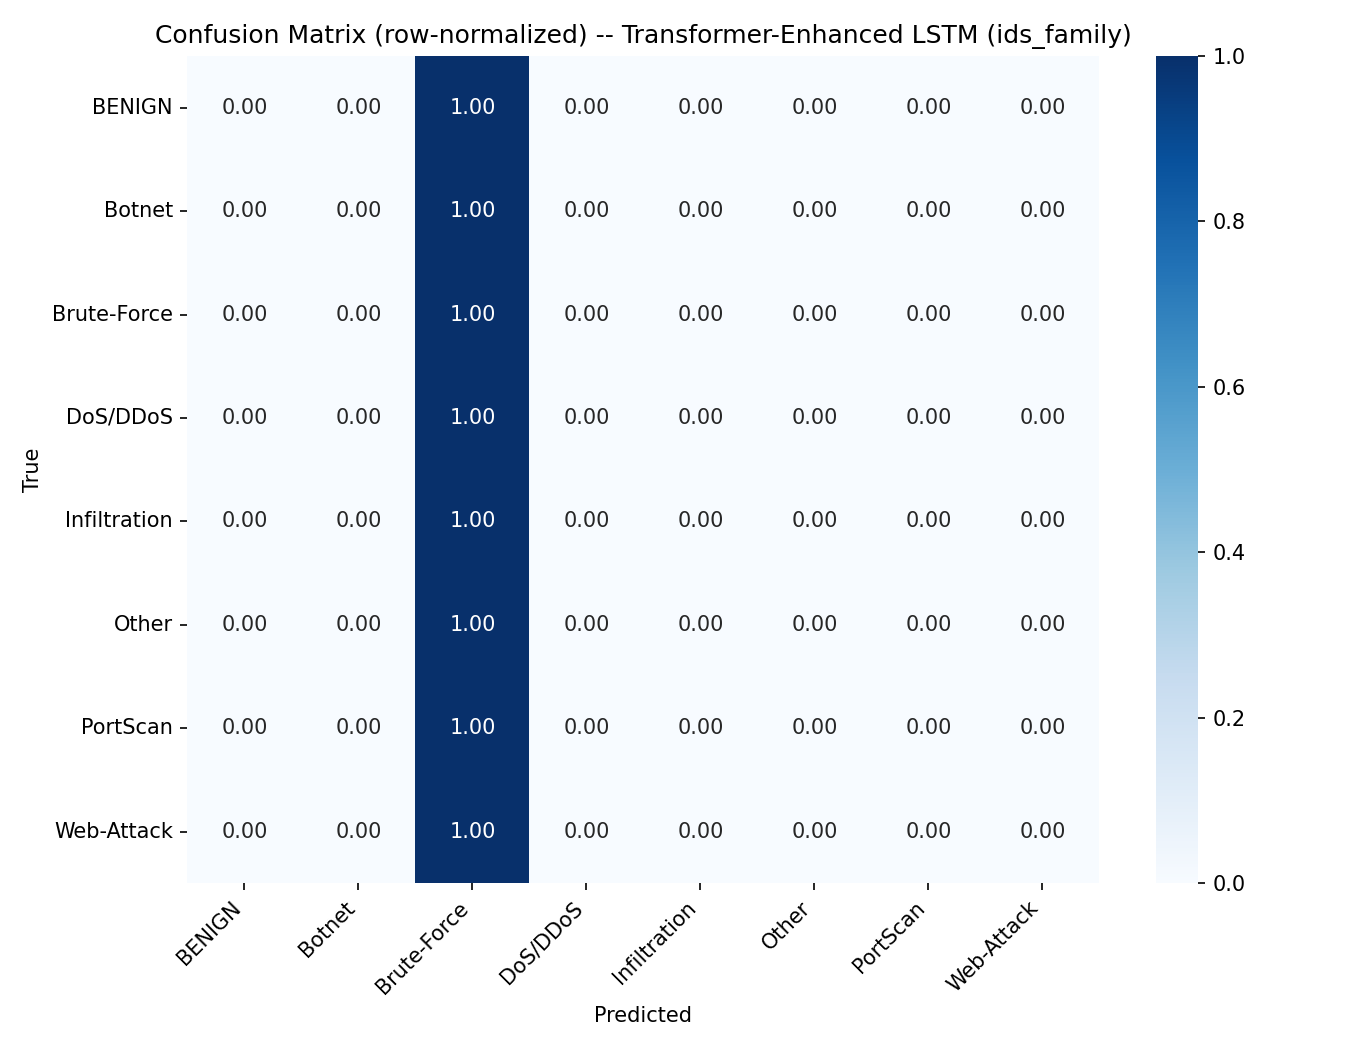

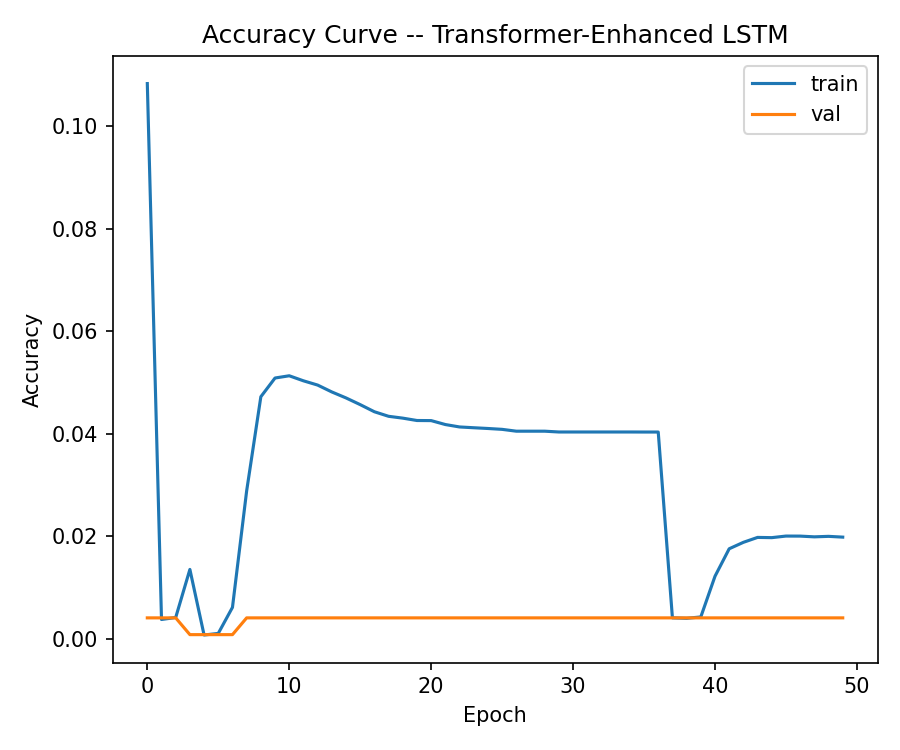

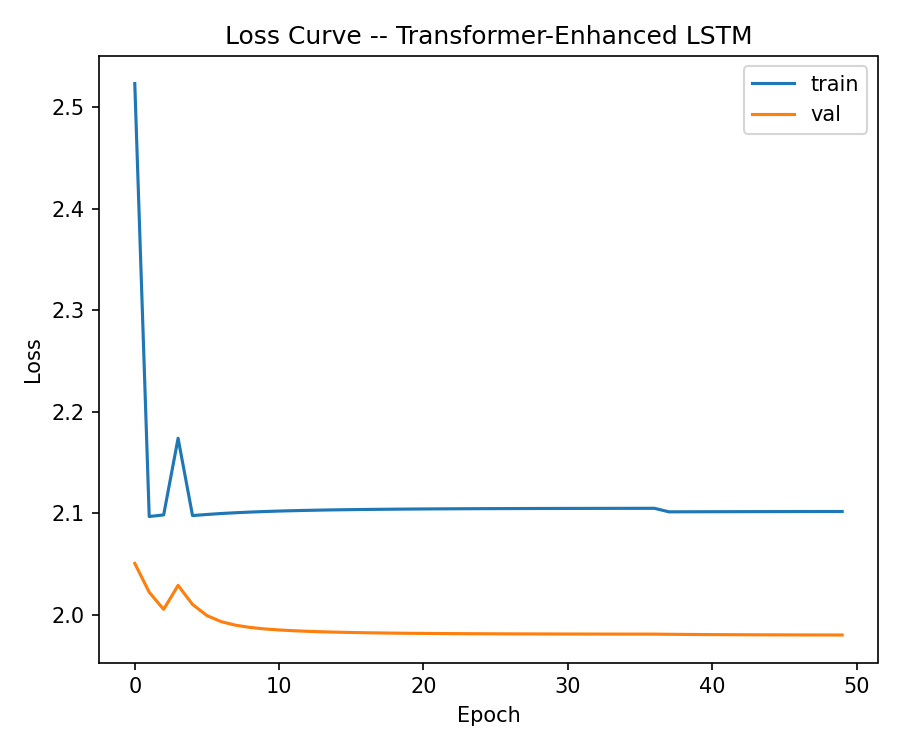

In [11]:
from IPython.display import Image, display

display(Image("results/ids_family/confusion_matrix.png"))
display(Image("results/ids_family/confusion_matrix_normalized.png"))
display(Image("figures/ids_family/accuracy_curve.png"))
display(Image("figures/ids_family/loss_curve.png"))

In [12]:
print(open("results/ids_family/metrics.txt").read())

Transformer-Enhanced LSTM -- ids_family classification (8 classes)

Accuracy:        0.0041
Macro F1:        0.0010
Weighted F1:     0.0000
Macro Precision: 0.0005
Macro Recall:    0.1250
Macro AUC (OvR): 0.5000

              precision    recall  f1-score   support

      BENIGN       0.00      0.00      0.00     94760
      Botnet       0.00      0.00      0.00        72
 Brute-Force       0.00      1.00      0.01       458
    DoS/DDoS       0.00      0.00      0.00     16085
Infiltration       0.00      0.00      0.00         2
       Other       0.00      0.00      0.00         1
    PortScan       0.00      0.00      0.00        92
  Web-Attack       0.00      0.00      0.00       107

    accuracy                           0.00    111577
   macro avg       0.00      0.12      0.00    111577
weighted avg       0.00      0.00      0.00    111577



## Task 3: `ids_multi` (fine attack types)

The full fine-grained attack-type label set, with the three Web Attack variants merged into one class and the ultra-rare Infiltration/Heartbleed classes dropped (see README for the exact rare-class handling). Judge by **macro-F1** and the confusion matrix, not accuracy. Not class-comparable to the CIC-Darknet2020 `application` task -- different problem domain, same model generalizing to a second dataset.

In [14]:
!python src/train.py    --task ids_multi

  CIC-IDS2017/Benign-Monday-no-metadata.parquet: shape=(458831, 78)
  CIC-IDS2017/Botnet-Friday-no-metadata.parquet: shape=(176038, 78)
  CIC-IDS2017/Bruteforce-Tuesday-no-metadata.parquet: shape=(389714, 78)
  CIC-IDS2017/DDoS-Friday-no-metadata.parquet: shape=(221264, 78)
  CIC-IDS2017/DoS-Wednesday-no-metadata.parquet: shape=(584991, 78)
  CIC-IDS2017/Infiltration-Thursday-no-metadata.parquet: shape=(207630, 78)
  CIC-IDS2017/Portscan-Friday-no-metadata.parquet: shape=(119522, 78)
  CIC-IDS2017/WebAttacks-Thursday-no-metadata.parquet: shape=(155820, 78)
Loaded 8 parquet files from CIC-IDS2017, combined shape (2313810, 78)
Replaced inf/-inf with NaN in 0 cells
Dropped 0 rows containing NaN
Dropped 82274 duplicate rows
Rows: 2313810 -> 2231536
Dropped 8 constant columns: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Subsampled 2231536 -> 557884 rows (stratified, f

In [ ]:
!python src/evaluate.py --task ids_multi

In [ ]:
from IPython.display import Image, display

display(Image("results/ids_multi/confusion_matrix.png"))
display(Image("results/ids_multi/confusion_matrix_normalized.png"))
display(Image("figures/ids_multi/accuracy_curve.png"))
display(Image("figures/ids_multi/loss_curve.png"))

In [ ]:
print(open("results/ids_multi/metrics.txt").read())

In [ ]:
# Optional: zip and download results + figures for all three tasks
# import shutil
# from google.colab import files
# shutil.make_archive("results", "zip", ".", "results")
# shutil.make_archive("figures", "zip", ".", "figures")
# files.download("results.zip")
# files.download("figures.zip")